# 04 — Baseline Model

Before any feature engineering: the deliberately trivial models the
roadmap calls for, trained on the fixed chronological split so there
is an honest, boring number on the board that every later, fancier
attempt has to actually beat. Two baselines, weakest first:

1. **Predict the training mean** — a floor under the floor. Any model
   that can't beat "ignore the input entirely" has no business being
   called a model.
2. **Plain linear regression** on the numeric columns already
   available, plus one-hot encoded `equipment` — minimal encoding,
   no engineered features, no target/frequency encoding of `pickup`/
   `delivery` (that's a feature-engineering decision, deferred on
   purpose). Both raw and log-transformed target versions are fit,
   since `03_eda.ipynb` found real skew and heavy tails in the raw
   target.

Both are evaluated on the same fixed split from `src/config.py`
(train Jan-Jul, tune Aug-Sep, test Oct) — the split is set once and
reused identically by every model in this project, so comparisons
down the line are apples-to-apples. This notebook fits on train and
reports on tune; test (October) stays untouched until the final model
comparison, per the roadmap.

In [1]:
import logging
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from src import config, data, evaluate, viz

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
viz.apply_theme()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

STAGE = "modeling"

INFO src.viz: Applied Spotter brand theme to matplotlib rcParams


## Load cleaned data and apply the fixed chronological split

Reading from `data/processed/` (sign-flip and fallback-distance fixes
already applied; `weight`/`market_index` missing values still `NaN`
on purpose, left for a pipeline-level imputer). The split itself
comes from `src/data.chronological_split`, using the cutoffs fixed in
`src/config.py` — every subsequent model calls this exact function
the same way, so no model gets a different, accidentally-easier or
harder split than another.

In [2]:
train_test = data.load_train_test_cleaned()
train, tune, test = data.chronological_split(train_test)

print(f"train: {len(train):,} rows ({train['date'].min()} - {train['date'].max()})")
print(f"tune:  {len(tune):,} rows ({tune['date'].min()} - {tune['date'].max()})")
print(f"test:  {len(test):,} rows ({test['date'].min()} - {test['date'].max()}) -- untouched until final comparison")

INFO src.data: Loading C:\dev\Spotter-ML-Engineer-Assessment\data\processed\train_test.csv
INFO src.data: Loaded train_test.csv: 48000 rows, 14 columns
INFO src.data: Chronological split: train=33718 (2025-01-01-2025-07-31), tune=9429 (2025-08-01-2025-09-30), test=4853 (2025-10-01-2025-10-31)


train: 33,718 rows (2025-01-01 - 2025-07-31)
tune:  9,429 rows (2025-08-01 - 2025-09-30)
test:  4,853 rows (2025-10-01 - 2025-10-31) -- untouched until final comparison


## Baseline 1 — predict the training mean

The floor under the floor. Ignores every input column; every
prediction is simply `train[posted_rate].mean()`. Any model that
can't beat this has learned nothing useful from the features.

In [3]:
train_mean = train[config.TARGET_COL].mean()
print(f"Training mean posted_rate: ${train_mean:,.2f}")

mean_baseline_pred = np.full(len(tune), train_mean)
mean_baseline_metrics = evaluate.regression_metrics(tune[config.TARGET_COL], mean_baseline_pred)
mean_baseline_metrics

INFO src.evaluate: Metrics (n=9429): RMSE=1499.43, MAE=1162.78, MAPE=82.74%, R2=-0.0000


Training mean posted_rate: $2,373.79


{'rmse': 1499.4261081485583,
 'mae': 1162.7809346899428,
 'mape': 82.73920203262523,
 'r2': -1.3083360135279776e-06,
 'n': 9429}

## Baseline 2 — plain linear regression

Minimal encoding only: the numeric columns already in the data used
directly (`distance`, `weight`, `market_index`, `quote_signal`), plus
`equipment` one-hot encoded (cheap at 3 categories — no cardinality
concern the way `pickup`/`delivery` would be). `weight` and
`market_index` missing values are imputed with the median, fit on
`train` only via a `sklearn.Pipeline`, so no statistic of `tune` or
`test` leaks into the imputer. `pickup_lat`/`lon` and
`delivery_lat`/`lon` are deliberately excluded — `01_profiling.ipynb`
already found `distance` correlates 0.9995 with the great-circle
distance those coordinates imply, so they add negligible information
beyond a column already present directly, and a plain linear model
would be especially exposed to that near-collinearity.

`03_eda.ipynb` found `posted_rate` is right-skewed (1.90) with a
heavy tail (excess kurtosis 13.28), both resolved by a log transform
(-0.49 / 0.14). Both the raw-target and log-target versions are fit
here, since a linear model is exactly the kind of model that's
sensitive to that skew.

In [4]:
numeric_features = ["distance", "weight", "market_index", "quote_signal"]
categorical_features = ["equipment"]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), numeric_features),
        ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ]
)

X_train = train[numeric_features + categorical_features]
X_tune = tune[numeric_features + categorical_features]
y_train = train[config.TARGET_COL]
y_tune = tune[config.TARGET_COL]

### Raw-target linear regression

In [5]:
linear_raw = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression()),
])
linear_raw.fit(X_train, y_train)

linear_raw_pred = linear_raw.predict(X_tune)
linear_raw_metrics = evaluate.regression_metrics(y_tune, linear_raw_pred)
linear_raw_metrics

INFO src.evaluate: Metrics (n=9429): RMSE=629.81, MAE=164.96, MAPE=8.93%, R2=0.8236


{'rmse': 629.8081273310494,
 'mae': 164.961605635116,
 'mape': 8.930647546408512,
 'r2': 0.823572226892533,
 'n': 9429}

### Log-target linear regression

Same features, same preprocessing -- the only difference is fitting
on `log(posted_rate)` and exponentiating predictions back to dollars
before scoring, so its metrics are directly comparable to the
raw-target version above (both reported in $, not log-$).

In [6]:
linear_log = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression()),
])
linear_log.fit(X_train, np.log(y_train))

linear_log_pred = np.exp(linear_log.predict(X_tune))
linear_log_metrics = evaluate.regression_metrics(y_tune, linear_log_pred)
linear_log_metrics

INFO src.evaluate: Metrics (n=9429): RMSE=938.65, MAE=479.91, MAPE=22.28%, R2=0.6081


{'rmse': 938.6489663832979,
 'mae': 479.90865563231296,
 'mape': 22.281928539105106,
 'r2': 0.6081166214298063,
 'n': 9429}

## Comparing all three

In [7]:
comparison = evaluate.metrics_table({
    "mean_baseline": mean_baseline_metrics,
    "linear_raw": linear_raw_metrics,
    "linear_log": linear_log_metrics,
})
comparison.round(3)

,rmse,mae,mape,r2,n
linear_raw,629.808,164.962,8.931,0.824,9429.0
linear_log,938.649,479.909,22.282,0.608,9429.0
mean_baseline,1499.426,1162.781,82.739,-0.000,9429.0


Both linear baselines clear the mean-only floor by a wide margin, as
expected — `distance` alone carries a 0.91 correlation with the
target, so even a bare-bones linear fit captures most of that. But
the raw-vs-log comparison itself came out the opposite of what EDA's
skew and kurtosis numbers would suggest: `linear_raw` beats
`linear_log` on every single metric, not narrowly (RMSE 630 vs. 939,
MAE 165 vs. 480, MAPE 8.9% vs. 22.3%, R² 0.82 vs. 0.61). Worth
understanding why rather than just reporting the number, since a
result this lopsided against the EDA-motivated expectation deserves
an explanation, not just acceptance.

In [8]:
tune_quartiles = tune.assign(raw_pred=linear_raw_pred, log_pred=linear_log_pred)
tune_quartiles["rate_quartile"] = pd.qcut(
    tune_quartiles[config.TARGET_COL], 4, labels=["Q1 (cheapest)", "Q2", "Q3", "Q4 (priciest)"]
)

quartile_mape = tune_quartiles.groupby("rate_quartile", observed=True).apply(
    lambda g: pd.Series({
        "n": len(g),
        "raw_mape": (np.abs(g["raw_pred"] - g[config.TARGET_COL]) / g[config.TARGET_COL]).mean() * 100,
        "log_mape": (np.abs(g["log_pred"] - g[config.TARGET_COL]) / g[config.TARGET_COL]).mean() * 100,
    })
)
quartile_mape.round(1)

C:\Users\ingex\AppData\Local\Temp\ipykernel_23412\102149211.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  quartile_mape = tune_quartiles.groupby("rate_quartile", observed=True).apply(


,n,raw_mape,log_mape
rate_quartile,,,
Q1 (cheapest),2358.0,19.6,34.6
Q2,2357.0,6.4,16.7
Q3,2357.0,4.5,19.8
Q4 (priciest),2357.0,5.2,18.0


`linear_log` loses to `linear_raw` in **every** rate quartile, not
just at the extremes — this isn't a story about a few outliers
dragging one model down, it's systematic. The mechanism: predictions
are fit in log-space and then exponentiated back to dollars before
scoring. A plain, unregularized linear fit with only five features
doesn't have much flexibility to place each log-space prediction
precisely, and `exp()` amplifies whatever error remains — a small
absolute miss in log-space becomes a large multiplicative miss in
dollar terms, hitting cheap loads hardest (Q1 MAPE: 19.6% raw vs.
34.6% log) but visibly present all the way up through the priciest
quartile too (Q4: 5.2% raw vs. 18.0% log).

This doesn't mean the log-transform idea from EDA was wrong — the
skew and kurtosis numbers were real and accurately described. What it
means is that *this specific model* (plain linear regression, five
features, no regularization) isn't the right vehicle to benefit from
it. A tree-based model, which doesn't fit in a single global
log-linear relationship the way this one does, or a linear model with
more features and some regularization, could plausibly behave
differently — that's a live question for the model comparison phase,
not resolved here. For this baseline specifically: **`linear_raw` is
the one every later model has to beat**, and the log-target version
is kept in the comparison table as a documented, explained result
rather than dropped silently.

## Diagnostics on the winning baseline

Actual-vs-predicted and residuals-vs-predicted for `linear_raw`, the
baseline that actually won on `tune` — the standard pair for checking
whether errors are centered near zero and whether error grows with
the predicted value.

In [9]:
better_name, better_pred = "linear_raw", linear_raw_pred
print(f"Winning baseline on tune RMSE: {better_name}")

Winning baseline on tune RMSE: linear_raw


INFO src.viz: Plotting actual vs. predicted: Actual vs. predicted -- linear_raw (tune) (n=9429)
INFO src.viz: Saved figure to C:\dev\Spotter-ML-Engineer-Assessment\figures\modeling\baseline_linear_raw_actual_vs_predicted.png


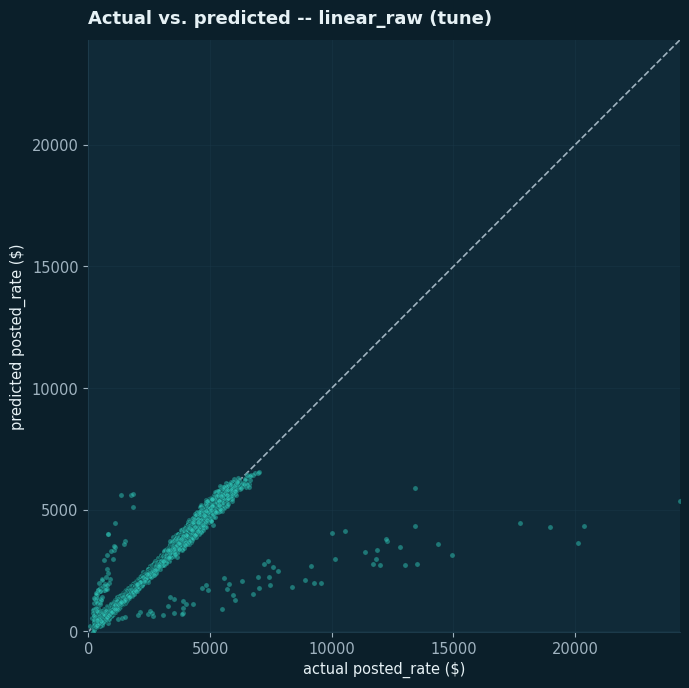

In [10]:
fig = viz.plot_actual_vs_predicted(
    y_tune, better_pred, stage=STAGE, filename=f"baseline_{better_name}_actual_vs_predicted.png",
    title=f"Actual vs. predicted -- {better_name} (tune)",
)

INFO src.viz: Plotting residuals: Residuals -- linear_raw (tune) (n=9429)
INFO src.viz: Saved figure to C:\dev\Spotter-ML-Engineer-Assessment\figures\modeling\baseline_linear_raw_residuals.png


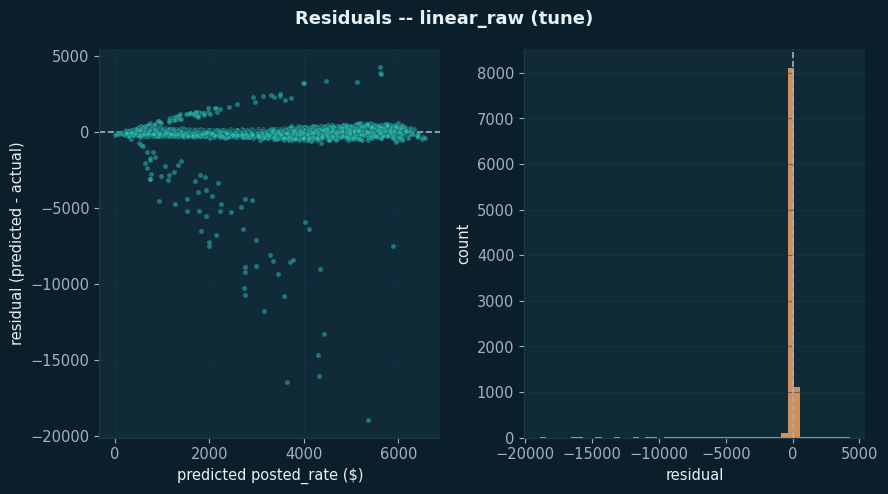

In [11]:
resid = evaluate.residuals(y_tune, better_pred)
fig = viz.plot_residuals(
    better_pred, resid, stage=STAGE, filename=f"baseline_{better_name}_residuals.png",
    title=f"Residuals -- {better_name} (tune)",
)

The residual-vs-predicted panel shows spread widening as the
predicted rate increases — classic heteroscedasticity, and the same
pattern already visible in the raw rate-vs-distance scatter back in
`03_eda.ipynb`. It's also a second, independent confirmation of why
`linear_log` underperformed here rather than helping: the variance
genuinely does grow with the level of the target, which is exactly
the situation a log-transform is supposed to help with in principle —
it just didn't, for this specific low-flexibility model. The actual-
vs-predicted panel shows the model tracking the bulk of the data
reasonably well along the diagonal, with the known long-haul outliers
(the $20k+ loads confirmed as real, not errors, in EDA) sitting well
below the line — under-predicted, as expected, since nothing in a
5-feature linear model can capture what makes a specific load a
premium long-haul job.

## Summary

| MODEL          | RMSE   | MAE     | MAPE   | R2     | n      |
|----------------|--------|---------|--------|--------|--------|
| linear_raw     | 629.808| 164.962 | 8.931  | 0.824  | 9429.0 |
| linear_log     | 938.649| 479.909 | 22.282 | 0.608  | 9429.0 |
| mean_baseline  | 1499.426| 1162.781| 82.739 | -0.000 | 9429.0 |

**Split used**: fixed chronological cutoffs from `src/config.py`
(train Jan-Jul, tune Aug-Sep, test Oct — test untouched). Every model
from here forward reuses this exact split via
`data.chronological_split`.

**Features used**: `distance`, `weight`, `market_index`,
`quote_signal` (numeric, median-imputed on train only), `equipment`
(one-hot). Coordinates excluded (redundant with `distance`, confirmed
in profiling). `pickup`/`delivery` city names excluded (cardinality
decision deferred to feature engineering, per the roadmap).

**Result**: both linear baselines clear the mean-only floor
substantially, confirming `distance` alone is doing real work even
with zero feature engineering. `linear_raw` beat `linear_log` on
every metric and in every rate quartile — a genuine, checked result,
not a coin flip. The mechanism is specific to a plain, low-flexibility
linear model exponentiating log-space error back into dollars, not
evidence that the log-transform idea from EDA was mistaken; it stays
a live option to re-test once a more flexible model is in the
comparison.

**What every later model has to beat**: `linear_raw`'s row in the
`comparison` table above (RMSE ≈ 630, MAE ≈ 165, MAPE ≈ 8.9%,
R² ≈ 0.82 on `tune`).

**Carried into `05_feature_engineering.ipynb`:**
1. `linear_raw` is the baseline to beat; log-target stays a documented
   option to re-test with a more flexible model, not a closed
   question.
2. `pickup`/`delivery` cardinality (64 cities each) is the first real
   feature-engineering decision — target encoding, frequency
   encoding, or a model with native categorical support, weighed
   against one-hot's 120+ column cost flagged back in profiling.
3. The residual plot's widening spread at higher predicted rates is a
   concrete, evaluated signal (not just an EDA hunch) that
   heteroscedasticity is real and worth addressing — either through
   features that explain more of what drives the priciest loads, or
   through a model family more naturally suited to it.